In [15]:
# Cell 1: Imports & Parameter
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from itables import init_notebook_mode, show

from utils.parquet_io import load_parquet
# >>> Pfad zu DEINEM Run anpassen:
run_dir = Path(r"C:\Dev\Bachelorarbeit\data\accounting\runs\lamda_gamma_opt\icvar_ppo_S1_lamda_5\ppo_icvar_state1_walkforward_20260102_132510\E2\fold_01\test\test_2018")
paths = [f"Path_{i:02d}" for i in range(1, 6)]

def load_and_info(path: Path) -> pd.DataFrame:
    """Lädt ein Parquet und gibt Infos aus."""
    df = load_parquet(path)
    print(f"\n--- {path.name} ---")
    print(f"Shape: {df.shape}")
    print(f"Columns: {len(df.columns)}")
    return df


In [16]:
df_btc = load_and_info(run_dir / "rewards.parquet")
display(df_btc.head(255), df_btc.tail())


--- rewards.parquet ---
Shape: (250, 18)
Columns: 18


,round,t,nav_t,nav_t-1,r_log_t,var_t,cvar_t,cvar_tminus1,icvar_t,delta_mdd_t,reward_t,reward_kind,icvar_mode,alpha,lambda_,gamma,estimator,ewm_alpha
index,,,,,,,,,,,,,,,,,,
1,905,2018-01-03 00:00:00+00:00,1.000039e+06,1.000000e+06,0.000039,NaN,NaN,NaN,0.000000,0.0,0.000039,icvar,ex_ante,0.05,5.0,0.0,rolling,0.1
2,906,2018-01-04 00:00:00+00:00,1.000078e+06,1.000039e+06,0.000039,NaN,NaN,NaN,0.000000,0.0,0.000039,icvar,ex_ante,0.05,5.0,0.0,rolling,0.1
3,907,2018-01-05 00:00:00+00:00,1.000117e+06,1.000078e+06,0.000039,NaN,NaN,NaN,0.000000,0.0,0.000039,icvar,ex_ante,0.05,5.0,0.0,rolling,0.1
4,908,2018-01-08 00:00:00+00:00,1.000157e+06,1.000117e+06,0.000040,NaN,NaN,NaN,0.000000,0.0,0.000040,icvar,ex_ante,0.05,5.0,0.0,rolling,0.1
5,909,2018-01-09 00:00:00+00:00,1.000197e+06,1.000157e+06,0.000040,NaN,NaN,NaN,0.000000,0.0,0.000040,icvar,ex_ante,0.05,5.0,0.0,rolling,0.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
246,1150,2018-12-24 00:00:00+00:00,5.360965e+05,5.159159e+05,0.038370,0.020645,0.042618,0.042056,0.000562,0.0,0.035560,icvar,ex_ante,0.05,5.0,0.0,rolling,0.1
247,1151,2018-12-26 00:00:00+00:00,5.322572e+05,5.360965e+05,-0.007187,0.020640,0.043112,0.042618,0.000494,0.0,-0.009659,icvar,ex_ante,0.05,5.0,0.0,rolling,0.1
248,1152,2018-12-27 00:00:00+00:00,5.246251e+05,5.322572e+05,-0.014443,0.020635,0.043546,0.043112,0.000433,0.0,-0.016611,icvar,ex_ante,0.05,5.0,0.0,rolling,0.1


,round,t,nav_t,nav_t-1,r_log_t,var_t,cvar_t,cvar_tminus1,icvar_t,delta_mdd_t,reward_t,reward_kind,icvar_mode,alpha,lambda_,gamma,estimator,ewm_alpha
index,,,,,,,,,,,,,,,,,,
246,1150,2018-12-24 00:00:00+00:00,536096.469765,515915.861882,0.038370,0.020645,0.042618,0.042056,0.000562,0.0,0.035560,icvar,ex_ante,0.05,5.0,0.0,rolling,0.1
247,1151,2018-12-26 00:00:00+00:00,532257.233398,536096.469765,-0.007187,0.020640,0.043112,0.042618,0.000494,0.0,-0.009659,icvar,ex_ante,0.05,5.0,0.0,rolling,0.1
248,1152,2018-12-27 00:00:00+00:00,524625.062773,532257.233398,-0.014443,0.020635,0.043546,0.043112,0.000433,0.0,-0.016611,icvar,ex_ante,0.05,5.0,0.0,rolling,0.1
249,1153,2018-12-28 00:00:00+00:00,535671.124250,524625.062773,0.020837,0.020629,0.043924,0.043546,0.000379,0.0,0.018943,icvar,ex_ante,0.05,5.0,0.0,rolling,0.1
250,1154,2018-12-31 00:00:00+00:00,537531.959126,535671.124250,0.003468,0.020624,0.044254,0.043924,0.000330,0.0,0.001819,icvar,ex_ante,0.05,5.0,0.0,rolling,0.1


In [3]:
# Cell 2: Laden und auf breites Format bringen (eine Spalte je Path)
wide = None

for pid in paths:
    print(pid)
    p = run_dir / pid
    f_rewards = p / "rewards.parquet"
    f_snap    = p / "portfolio_snapshots.parquet"

    if f_rewards.is_file():
        df = load_parquet(f_rewards)
    elif f_snap.is_file():
        df = load_parquet(f_snap)
    else:
        print(f"⚠️ Keine rewards/portfolio_snapshots in {pid}")
        continue

    # Datum/Zeit holen
    if "date" in df.columns:
        idx = pd.to_datetime(df["date"], utc=True, errors="coerce")
    elif "timestamp" in df.columns:
        idx = pd.to_datetime(df["timestamp"], unit="s", utc=True, errors="coerce")
    else:
        idx = pd.to_datetime(df.index, utc=True, errors="coerce")

    # Reward-Spalte finden
    reward_col = next((c for c in ["reward_t","rewards","rwd","step_reward"] if c in df.columns), None)
    if reward_col is None:
        print(f"⚠️ Keine Reward-Spalte in {pid}")
        continue

    s = pd.Series(df[reward_col].values, index=idx, name=pid).sort_index()
    s = s[~s.index.duplicated(keep="last")]  # doppelte Timestamps entfernen

    wide = s.to_frame() if wide is None else wide.join(s, how="outer")

if wide is None:
    raise SystemExit("Keine Daten geladen.")

wide = wide.sort_index()


Path_01
Path_02
Path_03
Path_04
Path_05


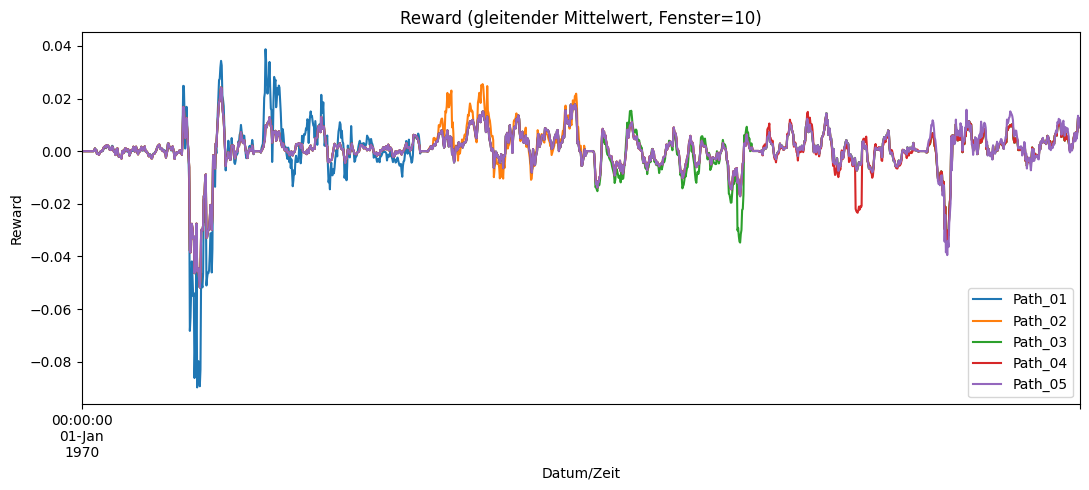

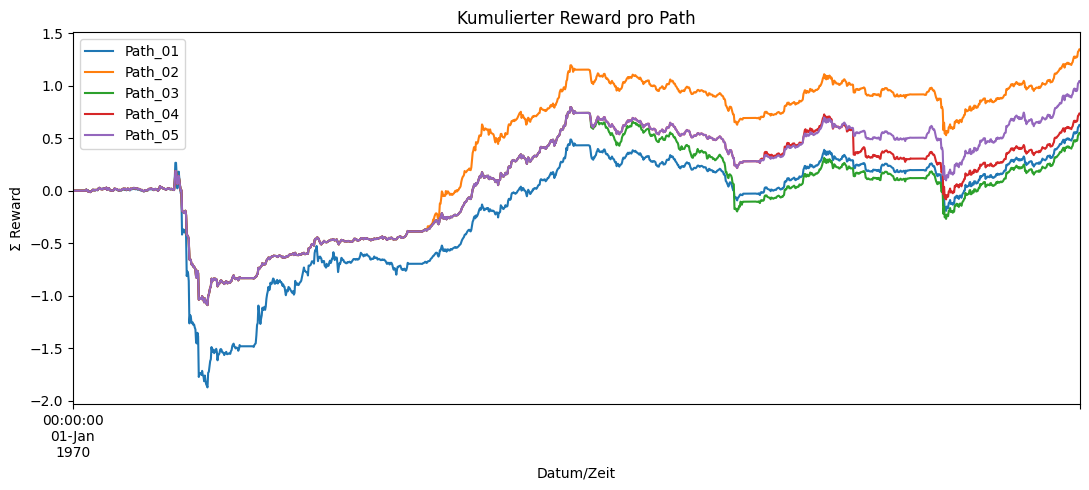

In [4]:
# (Optional) Glättung und/oder kumulierter Reward zum besseren Vergleich
# Glätten:
wide_smooth = wide.rolling(10, min_periods=1).mean()
ax = wide_smooth.plot(figsize=(11,5))
ax.set_title("Reward (gleitender Mittelwert, Fenster=10)")
ax.set_xlabel("Datum/Zeit"); ax.set_ylabel("Reward")
plt.tight_layout(); plt.show()

# Kumuliert:
wide_cum = wide.fillna(0).cumsum()
ax = wide_cum.plot(figsize=(11,5))
ax.set_title("Kumulierter Reward pro Path")
ax.set_xlabel("Datum/Zeit"); ax.set_ylabel("Σ Reward")
plt.tight_layout(); plt.show()


In [5]:
# Cell 2: Laden und auf breites Format bringen (eine Spalte je Path)
wide = None

for pid in paths:

    p = run_dir / pid
    f_rewards = p / "rewards.parquet"
    f_snap    = p / "portfolio_snapshots.parquet"

    if f_rewards.is_file():
        df = load_parquet(f_rewards)
    elif f_snap.is_file():
        df = load_parquet(f_snap)
    else:
        print(f"⚠️ Keine rewards/portfolio_snapshots in {pid}")
        continue

    # Datum/Zeit holen
    if "date" in df.columns:
        idx = pd.to_datetime(df["date"], utc=True, errors="coerce")
    elif "timestamp" in df.columns:
        idx = pd.to_datetime(df["timestamp"], unit="s", utc=True, errors="coerce")
    else:
        idx = pd.to_datetime(df.index, utc=True, errors="coerce")

    # Reward-Spalte finden
    reward_col = next((c for c in ["nav_t"] if c in df.columns), None)
    if reward_col is None:
        print(f"⚠️ Keine Reward-Spalte in {pid}")
        continue

    s = pd.Series(df[reward_col].values, index=idx, name=pid).sort_index()
    s = s[~s.index.duplicated(keep="last")]  # doppelte Timestamps entfernen

    wide = s.to_frame() if wide is None else wide.join(s, how="outer")

if wide is None:
    raise SystemExit("Keine Daten geladen.")

wide = wide.sort_index()


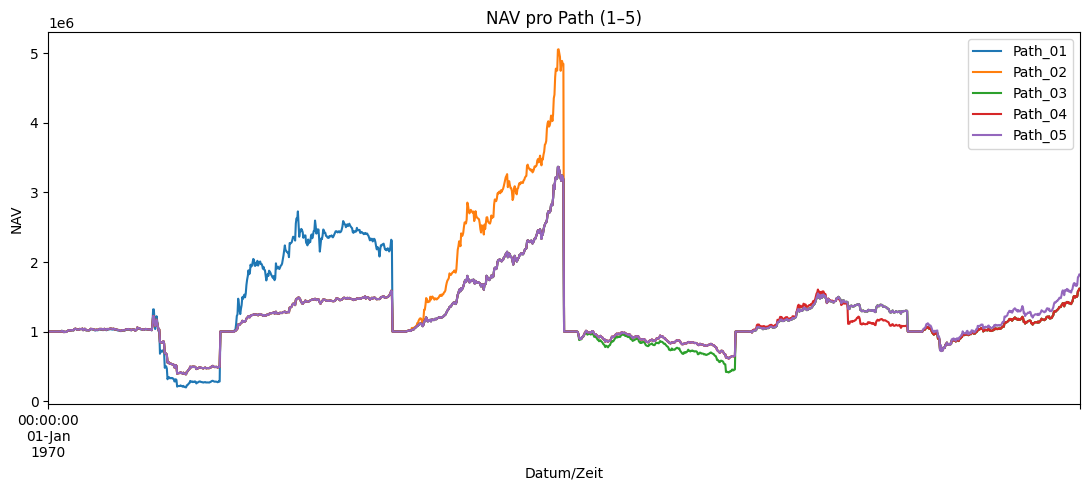

In [6]:
# Cell 3: Plot – Reward pro Path (roh)
ax = wide.plot(figsize=(11,5))
ax.set_title("NAV pro Path (1–5)")
ax.set_xlabel("Datum/Zeit")
ax.set_ylabel("NAV")
plt.tight_layout(); plt.show()

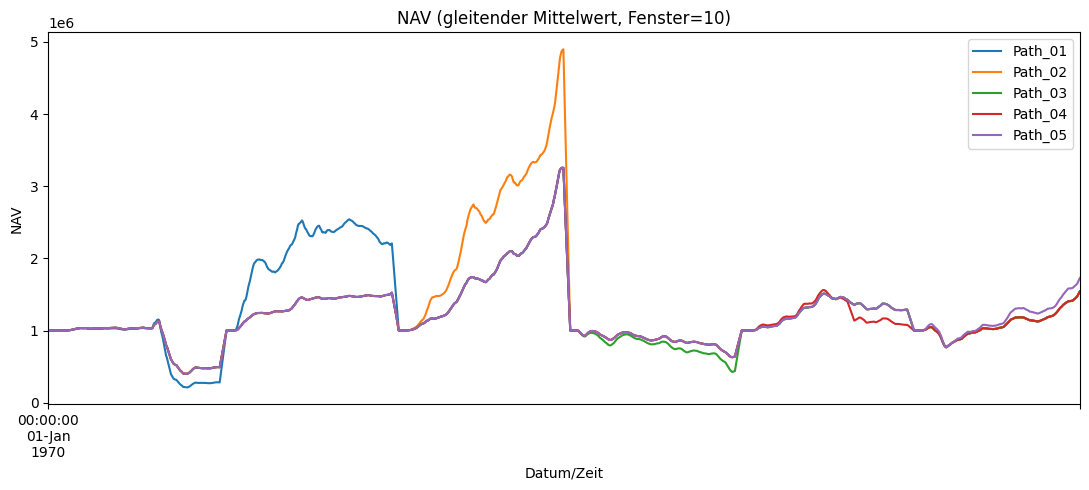

In [7]:
# (Optional) Glättung und/oder kumulierter Reward zum besseren Vergleich
# Glätten:
wide_smooth = wide.rolling(10, min_periods=1).mean()
ax = wide_smooth.plot(figsize=(11,5))
ax.set_title("NAV (gleitender Mittelwert, Fenster=10)")
ax.set_xlabel("Datum/Zeit"); ax.set_ylabel("NAV")
plt.tight_layout(); plt.show()


In [3]:
wide = None

for pid in paths:
    print(pid)
    p = run_dir / pid
    f_trade   = p / "trade_events.parquet"


    if f_trade.is_file():
        df = load_parquet(f_trade)
    else:
        print(f"⚠️ Keine rewards/portfolio_snapshots in {pid}")
        continue

    # Datum/Zeit holen
    if "date" in df.columns:
        idx = pd.to_datetime(df["date"], utc=True, errors="coerce")
    elif "timestamp" in df.columns:
        idx = pd.to_datetime(df["timestamp"], unit="s", utc=True, errors="coerce")
    else:
        idx = pd.to_datetime(df.index, utc=True, errors="coerce")

    # Reward-Spalte finden
    reward_col = next((c for c in ["reward_t","rewards","rwd","step_reward"] if c in df.columns), None)
    if reward_col is None:
        print(f"⚠️ Keine Reward-Spalte in {pid}")
        continue

    s = pd.Series(df[reward_col].values, index=idx, name=pid).sort_index()
    s = s[~s.index.duplicated(keep="last")]  # doppelte Timestamps entfernen

    wide = s.to_frame() if wide is None else wide.join(s, how="outer")


df_btc = load_and_info(f_trade)
display(df_btc)

Path_01
⚠️ Keine rewards/portfolio_snapshots in Path_01
Path_02
⚠️ Keine rewards/portfolio_snapshots in Path_02
Path_03
⚠️ Keine rewards/portfolio_snapshots in Path_03
Path_04
⚠️ Keine rewards/portfolio_snapshots in Path_04
Path_05
⚠️ Keine rewards/portfolio_snapshots in Path_05


FileNotFoundError: Parquet file not found: C:\Dev\Bachelorarbeit\data\accounting\runs\cpcv_baseline\icvar_ppo_S1_final\ppo_icvar_state1_cpcv_20251228_112337\E2\Path_05\trade_events.parquet

FileNotFoundError: Parquet file not found: C:\Dev\Bachelorarbeit\data\accounting\runs\cpcv_baseline\icvar_ppo_S1_final\ppo_icvar_state1_cpcv_20251228_112337\E2\Path_05\trade_events.parquet